# Baseline - Content Based

Three news recommendation systems were constructed and evaluated, using the dataset MIND. The adopted methods include content-based filtering (using TF-IDF/ Bert/SBert) and collaborative filtering (based on the embedding model of pytorch). The evaluation methods are Precision@K, MRR@K, NDGC@K, Recall@K, The proportion of the number of news items actually clicked by users to the total number of news items actually clicked by users.

## 1. Load data

In [ ]:
import os
import ast
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

from itertools import product
from tqdm.std import tqdm

import tensorflow as tf
from tensorflow.python.keras import layers

pd.set_option('display.max_columns', None)
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
import random
import numpy as np
import tensorflow as tf
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

2025-08-06 16:43:39.844007: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-06 16:43:40.035033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754462620.070919   57496 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754462620.083443   57496 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-06 16:43:40.291766: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Get input data

In [ ]:
behaviors = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


In [ ]:
news.head()

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [ ]:
behaviors.head()

,Impression_ID,User_ID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


## 2. Data Preprocessing


### Optionally simulate cold-start situation

restrict the amount of context per user to simulate new community.

In [ ]:
import pandas as pd

N = None  # keep at most N items

def pop_front_until_n(history_str, n):
    if pd.isna(history_str):
        return history_str
    items = history_str.strip().split()
    while len(items) > n:
        items.pop(0)  # pop from the front
    return ' '.join(items)

# permanently modify the "History" column
if N is not None:
    behaviors['History'] = behaviors['History'].apply(lambda s: pop_front_until_n(s, N))

### 2.1 Data Cleaning

In [ ]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviors['Impressions_parsed'] = behaviors['Impressions'].apply(parse_impressions)


In [ ]:
def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviors['History_parsed'] = behaviors['History'].apply(parse_history)


In [ ]:
behaviors

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N55189, N42782, N34694, N45794, N18445, N6330..."
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N31739, N6072, N63045, N23979, N35656, N43353..."
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N10732, N25792, N7563, N21087, N41087, N5445,..."
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N45729, N2203, N871, N53880, N41375, N43142, ..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]"
...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[(N2235, 0), (N22975, 0), (N64037, 0), (N47652...","[N7432, N58559, N1954, N43353, N14343, N13008,..."
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[(N3841, 0), (N61571, 0), (N58813, 0), (N28213...","[N9803, N104, N24462, N57318, N55743, N40526, ..."
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[(N55913, 0), (N62318, 0), (N53515, 0), (N1096...","[N29898, N59704, N4408, N9803, N53644, N26103,..."
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[(N6219, 0), (N3663, 0), (N31147, 0), (N58363,...","[N4118, N47297, N3164, N43295, N6056, N38747, ..."


In [ ]:
def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

In [ ]:
check_df_shape_and_null(news)
check_df_shape_and_null(behaviors)

The shape of df: (51282, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB

The number of missing values in each column:
News_ID                 0
Category                0
SubCategory             0
Title                   0
Abstract             2666
URL                     0
Title_Entities          3
Abstract_Entities       4
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 e

In [ ]:
news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviors_clean = behaviors.dropna()
behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

/tmp/ipykernel_57496/676842085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)
/tmp/ipykernel_57496/676842085.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)


dropna() is used to delete rows containing null values. This is particularly important in columns like Title, Abstract or Impressions, as this information is crucial in the process of content representation and label construction.

drop_duplicates() is used to remove duplicate entries based on News_ID in news.tsv and Impression_ID in drivs.tsv to avoid bias caused by duplicate data.

In [ ]:
check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviors_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (153727, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 153727 entries, 0 to 156964
Data columns (

### 2.2 Exploratory Data Analysis

The purpose is to better understand the data (the content of the news and user behavior)

So that the most suitable recommendation algorithm can be selected based on these features in the future, such as content recommendation or collaborative filtering, etc.

#### 2.2.1 EDA of News dataset

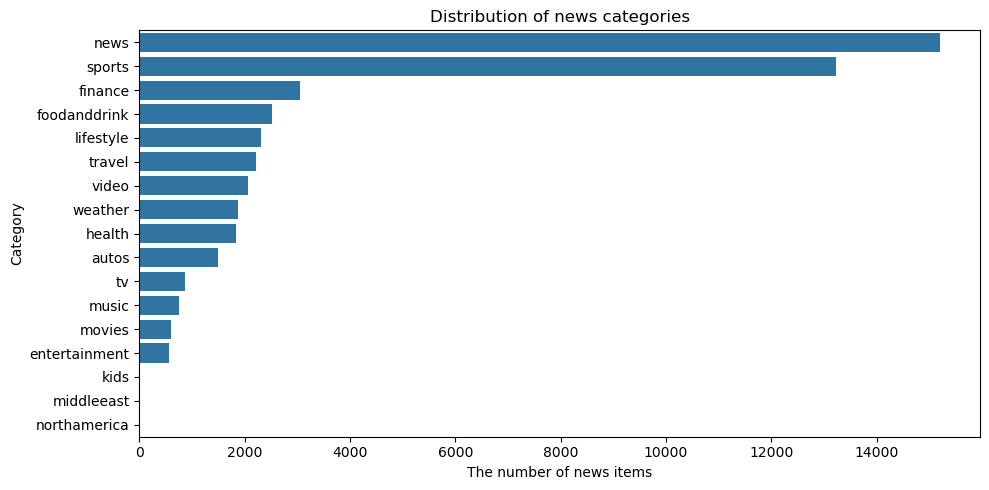

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=news_clean, y='Category', order=news_clean['Category'].value_counts().index)
plt.title('Distribution of news categories')
plt.xlabel('The number of news items')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57496/1120320366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcat.values, y=top_subcat.index, palette='cubehelix')


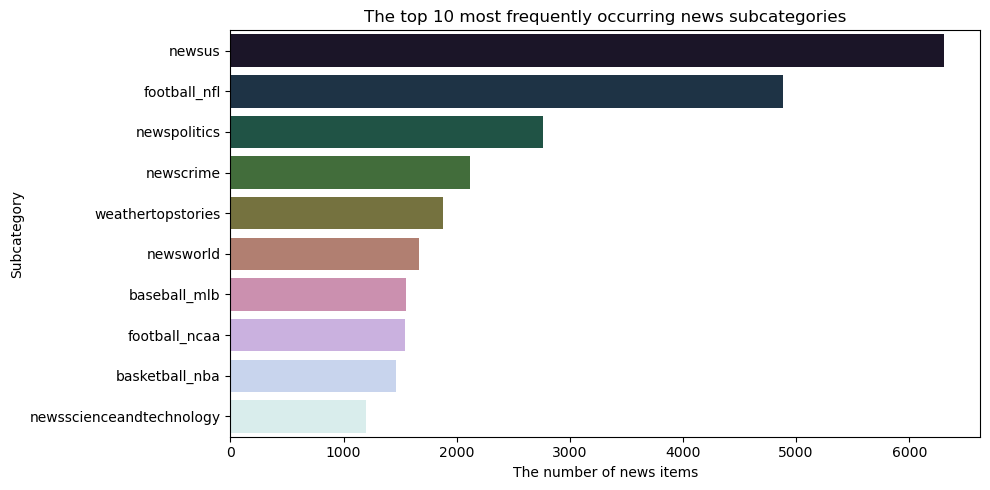

In [ ]:
top_subcat = news_clean['SubCategory'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_subcat.values, y=top_subcat.index, palette='cubehelix')
plt.title('The top 10 most frequently occurring news subcategories')
plt.xlabel('The number of news items')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57496/3542252221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_57496/3542252221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))


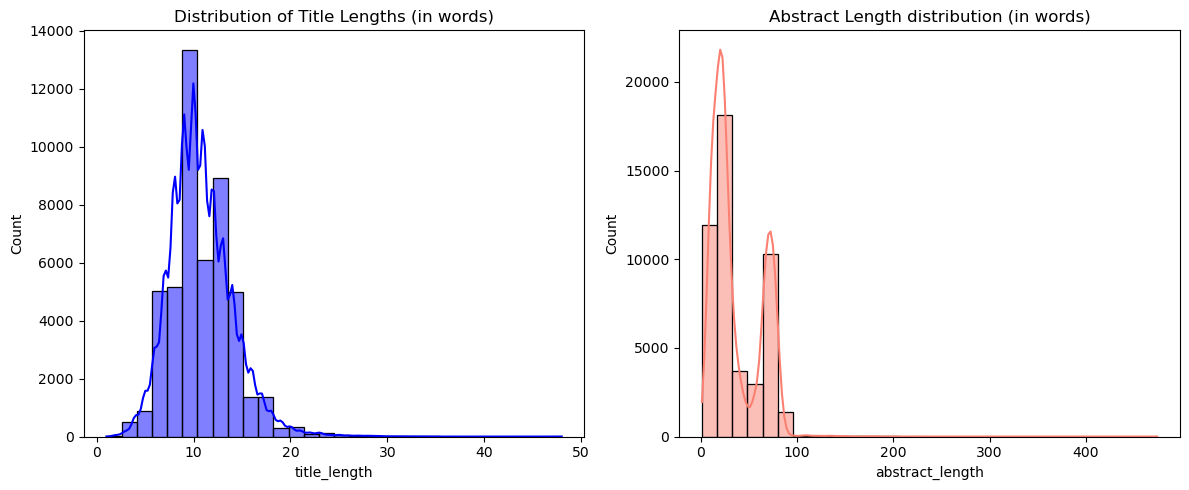

In [ ]:
news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(news_clean['title_length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Title Lengths (in words)')

plt.subplot(1, 2, 2)
sns.histplot(news_clean['abstract_length'], bins=30, kde=True, color='salmon')
plt.title('Abstract Length distribution (in words)')

plt.tight_layout()
plt.show()

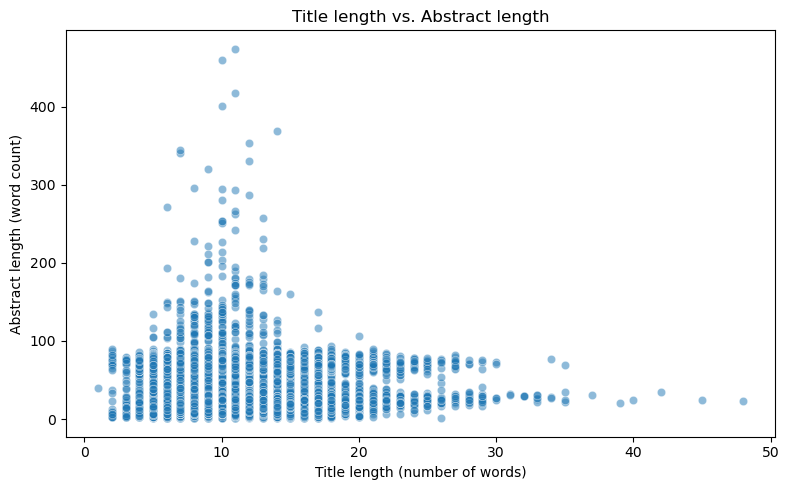

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=news_clean, x='title_length', y='abstract_length', alpha=0.5)
plt.title('Title length vs. Abstract length')
plt.xlabel('Title length (number of words)')
plt.ylabel('Abstract length (word count)')
plt.tight_layout()
plt.show()

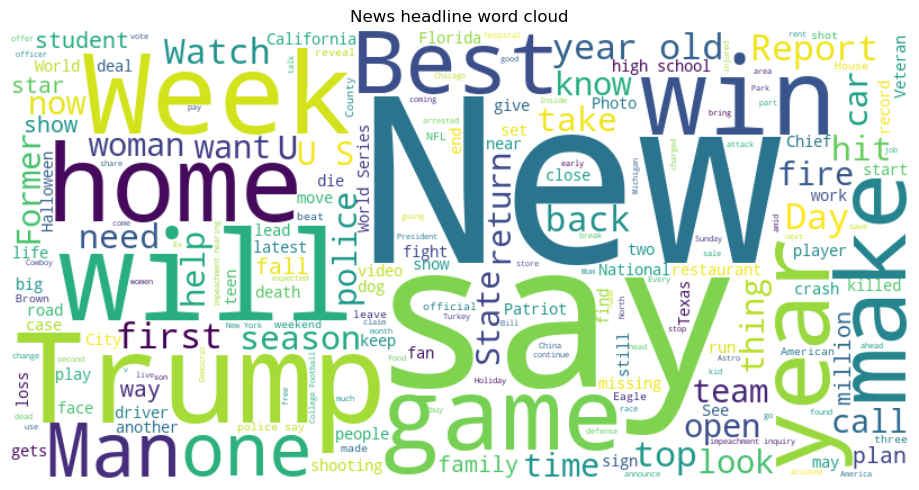

In [ ]:
from wordcloud import WordCloud

text_all_titles = ' '.join(news_clean['Title'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_all_titles)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('News headline word cloud')
plt.tight_layout()
plt.show()

### 2.2.2 EDA of user behaviour data

User's historical click-through count

count    153727.000000
mean         33.225387
std          40.408679
min           1.000000
25%           8.000000
50%          20.000000
75%          43.000000
max         558.000000
Name: history_len, dtype: float64


/tmp/ipykernel_57496/374645258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)


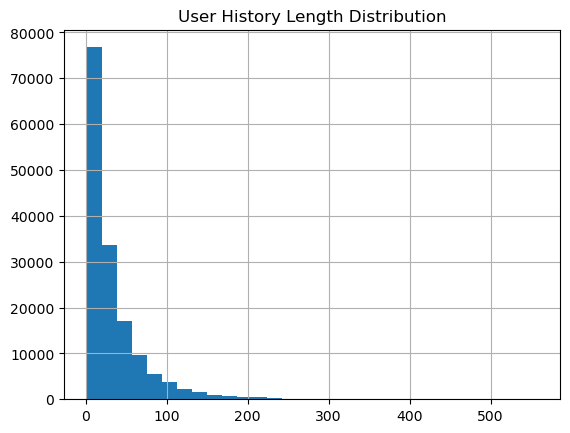

In [ ]:
behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)
print(behaviors_clean['history_len'].describe())

behaviors_clean['history_len'].hist(bins=30)
plt.title('User History Length Distribution')
plt.show()


The number of impressions of news each time

count    153727.000000
mean         37.228346
std          38.575186
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impr_num, dtype: float64


/tmp/ipykernel_57496/1653376557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))


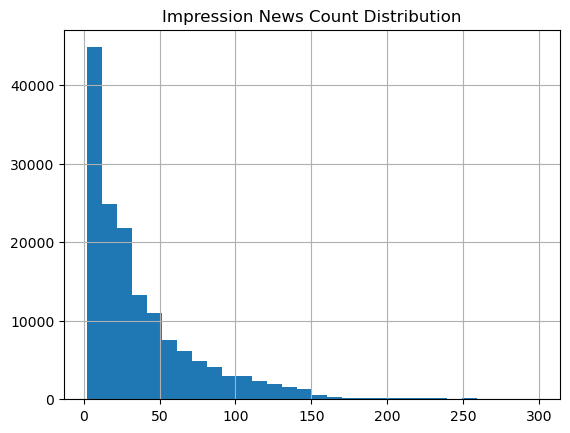

In [ ]:
behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))
print(behaviors_clean['impr_num'].describe())

behaviors_clean['impr_num'].hist(bins=30)
plt.title('Impression News Count Distribution')
plt.show()


the click-through rate per exposure

In [ ]:
def get_ctr(imp_str):
    if pd.isna(imp_str): return 0
    return sum(int(i.split('-')[1]) for i in imp_str.split()) / len(imp_str.split())

behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)
print(behaviors_clean['impr_ctr'].describe())

count    153727.000000
mean          0.108548
std           0.129526
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: impr_ctr, dtype: float64


/tmp/ipykernel_57496/3929120853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)


/tmp/ipykernel_57496/2884965371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)


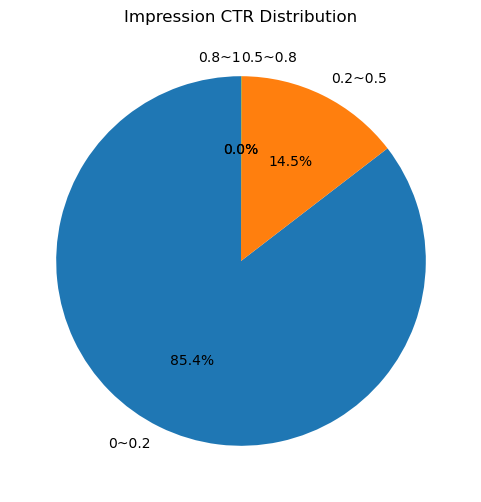

In [ ]:
import matplotlib.pyplot as plt

# bin behaviours
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['0~0.2', '0.2~0.5', '0.5~0.8', '0.8~1']
behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)

bin_counts = behaviors_clean['ctr_bin'].value_counts().sort_index()

# plot
plt.figure(figsize=(6, 6))
plt.pie(bin_counts, labels=bin_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Impression CTR Distribution')
plt.show()


#### explainations

1. **Distribution of News categories**
- Dominant categories: **news** and **sports**
The data distribution is unbalanced
Niche categories (such as *kids*, *middleeast*) belong to the ** long-tail distribution **

2. **Top-10 Subcategories **
The subcategories **newsus**, **football_nfl**, and **baseball_mlb** have the highest occurrence frequency
The *news* category has a high degree of diversity: demonstrating the potential for ** more fine-grained personalized recommendations **

3. Title and Abstract Length
- **Title** : Most are 10 to 15 words
- **Abstract** : Most are 30 to 100 words
For using "TF-IDF" to represent text features, such a length is already quite informative

4. Scatter plot of the lengths of the title and abstract
- No strong correlation: This indicates that the Title and Abstract are complementary information
Support merging the two into 'full_text' as a **joint input feature**

5. "Word Cloud Analysis of News Headlines
- the most common words include: "Trump", "New ", "say", "game", "week"
- The displayed news focuses on politics and sports, which can serve as a basis for themes or entity-level features

## 3. Feature Engineering & Data-preprocessing

### 3.1 Feature Extraction`full_text`

In [ ]:
news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']
display(news_clean[['News_ID', 'Category', 'full_text']].head(3))

/tmp/ipykernel_57496/729367934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']


,News_ID,Category,full_text
0,N55528,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,health,50 Worst Habits For Belly Fat. These seemingly...
2,N61837,news,The Cost of Trump's Aid Freeze in the Trenches...


#### 3.2 data clearning

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text=re.sub(r"[^\w\s'\-]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [ps.stem(word) for word in tokens]
    return ' '.join(tokens)

news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /home/raymo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/raymo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/raymo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_57496/139281858.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)


In [ ]:
selected_columns = ['News_ID', 'Category', 'SubCategory', 'Title', 'Abstract', 'full_text_clean']
df_selected = news_clean[selected_columns]

In [ ]:
df_selected

,News_ID,Category,SubCategory,Title,Abstract,full_text_clean
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",brand queen elizabeth princ charl princ philip...
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,50 worst habit belli fat seemingli harmless ha...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,cost trump 's aid freez trench ukrain 's war l...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",nba wife 's affect mental health felt like fra...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",get rid skin tag accord dermatologist seem har...
...,...,...,...,...,...,...
51275,N17258,news,newsscienceandtechnology,Realme takes chunk of India mobile market as S...,Over 400 percent more phones shipped year-on-year,realm take chunk india mobil market samsung sl...
51276,N23858,sports,golf,Young Northeast Florida fans flock to U.S. wom...,When the U.S. women's national soccer team arr...,young northeast florida fan flock u women 's s...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,adapt learn soul search reflect woolsey fire w...
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",st domin soccer player tri kick cancer curb so...


In [ ]:
news_clean

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities,title_length,abstract_length,full_text,full_text_clean
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],11,12,"The Brands Queen Elizabeth, Prince Charles, an...",brand queen elizabeth princ charl princ philip...
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",6,19,50 Worst Habits For Belly Fat. These seemingly...,50 worst habit belli fat seemingli harmless ha...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",12,36,The Cost of Trump's Aid Freeze in the Trenches...,cost trump 's aid freez trench ukrain 's war l...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",12,21,I Was An NBA Wife. Here's How It Affected My M...,nba wife 's affect mental health felt like fra...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...",11,31,"How to Get Rid of Skin Tags, According to a De...",get rid skin tag accord dermatologist seem har...
...,...,...,...,...,...,...,...,...,...,...,...,...
51275,N17258,news,newsscienceandtechnology,Realme takes chunk of India mobile market as S...,Over 400 percent more phones shipped year-on-year,https://assets.msn.com/labs/mind/BBWzDfx.html,"[{""Label"": ""Realme"", ""Type"": ""N"", ""WikidataId""...",[],10,7,Realme takes chunk of India mobile market as S...,realm take chunk india mobil market samsung sl...
51276,N23858,sports,golf,Young Northeast Florida fans flock to U.S. wom...,When the U.S. women's national soccer team arr...,https://assets.msn.com/labs/mind/BBWzQB8.html,"[{""Label"": ""First Coast"", ""Type"": ""G"", ""Wikida...","[{""Label"": ""United States women's national soc...",9,68,Young Northeast Florida fans flock to U.S. wom...,young northeast florida fan flock u women 's s...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,https://assets.msn.com/labs/mind/BBWzQJK.html,"[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...","[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...",9,22,"Adapting, Learning And Soul Searching: Reflect...",adapt learn soul search reflect woolsey fire w...
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",https://assets.msn.com/labs/mind/BBWzQnK.html,[],[],11,77,St. Dominic soccer player tries to kick cancer...,st domin soccer player tri kick cancer curb so...


The design purpose of this merge operation is to combine the brief information (title) with the more complete information (summary) as the input representation in the TF-IDF model. This step is very common in content-based recommendation systems because it can enhance semantic context (Ramos, 2003).

### 3.2. Create interactive df

For the Collaborative Filtering approach, an explicit data structure is required, consisting of User_ID, News_ID, and Label pairs (1 for clicked, 0 for not clicked).
This data is constructed by parsing the Impressions column from the behaviors_clean dataset.

In [ ]:
interactions_flat = []

for row in behaviors_clean.itertuples(index=False):  
    user_id = row.User_ID
    impressions = row.Impressions.split()
    for impression in impressions:
        if '-' in impression:
            news_id, label = impression.rsplit('-', 1)
            interactions_flat.append((user_id, news_id, int(label)))

interactions_df = pd.DataFrame(interactions_flat, columns=['User_ID', 'News_ID', 'Label'])
print("Total interactions:", len(interactions_df))


Total interactions: 5723002


In [ ]:
interactions_df

,User_ID,News_ID,Label
0,U13740,N55689,1
1,U13740,N35729,0
2,U91836,N20678,0
3,U91836,N39317,0
4,U91836,N58114,0
...,...,...,...
5722997,U44625,N39317,0
5722998,U64800,N61233,0
5722999,U64800,N33828,1
5723000,U64800,N19661,0


In [ ]:
interactions_df.groupby('Label')['Label'].value_counts()

Label
0    5491472
1     231530
Name: count, dtype: int64

In [ ]:
news_category = news_clean[['News_ID', 'Category']]
interactions_df = interactions_df.merge(news_category, on='News_ID', how='left')


In [ ]:
interactions_df.head()

,User_ID,News_ID,Label,Category
0,U13740,N55689,1,sports
1,U13740,N35729,0,news
2,U91836,N20678,0,sports
3,U91836,N39317,0,news
4,U91836,N58114,0,NaN


### 3.3. TF-IDF Feature Extraction

As a feature for Content-Based Filtering, text representation is extracted using the TF-IDF (Term Frequency–Inverse Document Frequency) method, which considers word importance based on both local and global occurrence.

### 3.4. Label Encoding for Collaborative Filtering

In [ ]:
user_encoder = LabelEncoder()
news_encoder = LabelEncoder()

interactions_df['user_encoded'] = user_encoder.fit_transform(interactions_df['User_ID'])
interactions_df['news_encoded'] = news_encoder.fit_transform(interactions_df['News_ID'])

num_users = interactions_df['user_encoded'].nunique()
num_items = interactions_df['news_encoded'].nunique()

print(f"Number of unique users: {num_users}")
print(f"Number of unique news items: {num_items}")

Number of unique users: 49108
Number of unique news items: 20252


In [ ]:
interactions_df

,User_ID,News_ID,Label,Category,user_encoded,news_encoded
0,U13740,N55689,1,sports,2201,15659
1,U13740,N35729,0,news,2201,8792
2,U91836,N20678,0,sports,47474,3670
3,U91836,N39317,0,news,47474,10061
4,U91836,N58114,0,NaN,47474,16502
...,...,...,...,...,...,...
5722997,U44625,N39317,0,news,20012,10061
5722998,U64800,N61233,0,weather,31669,17625
5722999,U64800,N33828,1,movies,31669,8140
5723000,U64800,N19661,0,news,31669,3330


#### Notes:
Encoding:
- Specific to the architecture of the Collaborative Filtering model
- Encoding depends on the number and distribution of users and items

### 3.5. Data Splitting for Train-Test (training model)

In [ ]:
X = interactions_df[['user_encoded', 'news_encoded']]
y = interactions_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Stratified sampling is conducted according to the category ratio of y to ensure that the ratio of positive and negative samples (such as clicked and unclicked) in the training set and the test set remains consistent.

In [ ]:
X_train, y_train

(         user_encoded  news_encoded
 3096247         36835          8081
 3421183         34182          5319
 4427003          6382         17181
 3083783         21848         15169
 2205544         27269         11868
 ...               ...           ...
 5052751          6796         13639
 2466162          2459          3527
 4767759         26459         12484
 152220          47161          3464
 4509053         15867         15321
 
 [4578401 rows x 2 columns],
 3096247    0
 3421183    0
 4427003    0
 3083783    0
 2205544    0
           ..
 5052751    0
 2466162    0
 4767759    0
 152220     0
 4509053    0
 Name: Label, Length: 4578401, dtype: int64)

## 4. Experiment

### 4.1. Content Based Filtering - TF-IDF

The Content-Based Filtering approach recommends news based on content similarity between articles, without taking into account the behavior of other users.
News content is represented by transforming the combined text of Title + Abstract into a fixed-dimensional TF-IDF vector.
Then, a k-Nearest Neighbors (k-NN) algorithm based on cosine similarity is used to find the most similar news articles.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

# Assuming news and behaviors dataframes are loaded as news_clean and behaviors_clean
# Add full_text_clean column by concatenating Title and Abstract
news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Note: If total span < 8 weeks, there may be overlap; if >8 weeks, middle unused

# Hyperparameter range
feature_range = [1000,3000, 5000, 7000]
K = 10
results = []

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((tfidf_matrix.shape[1],))
    return tfidf_matrix[indices].mean(axis=0).A1

# Recommend function (now also returns similarities for AUC)
def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = tfidf_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates (assuming all candidates are in newsid2idx)
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe for a given tfidf_matrix
def evaluate_df(df, tfidf_matrix, K):
    # Generate recommendations, sims, labels
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Tune on train
for max_f in feature_range:
    print(f"\n Testing max_features = {max_f}")
    
    vectorizer = TfidfVectorizer(max_features=max_f)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])
    
    train_results = evaluate_df(train_df, tfidf_matrix, K)
    
    results.append({
        'max_features': max_f,
        **train_results
    })

results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll results on train:")
print(results_df)

print(f"\nBest max_features found on train: {best_row['max_features']} with:")
for metric in ['precision@10', 'recall@10', 'mrr@10', 'ndcg@10', 'hit_rate@10', 'auc']:
    print(f" - {metric.capitalize()}: {best_row[metric]:.4f}")

# Evaluate on test with best
best_max_f = int(best_row['max_features'])
print(f"\nEvaluating best max_features ({best_max_f}) on test set")

vectorizer = TfidfVectorizer(max_features=best_max_f)
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])

test_results = evaluate_df(test_df, tfidf_matrix, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

/tmp/ipykernel_2398/3593379677.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']
/tmp/ipykernel_2398/3593379677.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])



 Testing max_features = 1000

 Testing max_features = 3000

 Testing max_features = 5000

 Testing max_features = 7000

All results on train:
   max_features  precision@10  recall@10    mrr@10   ndcg@10  hit_rate@10  \
0          1000      0.064507   0.516966  0.247759  0.301090     0.581310   
1          3000      0.065620   0.524174  0.258166  0.310066     0.589675   
2          5000      0.065692   0.524740  0.259183  0.310815     0.590352   
3          7000      0.065777   0.525474  0.260479  0.311919     0.591087   

        auc  
0  0.537427  
1  0.553457  
2  0.554595  
3  0.556844  

Best max_features found on train: 7000.0 with:
 - Precision@10: 0.0658
 - Recall@10: 0.5255
 - Mrr@10: 0.2605
 - Ndcg@10: 0.3119
 - Hit_rate@10: 0.5911
 - Auc: 0.5568

Evaluating best max_features (7000) on test set

Test set results:
 - Precision@10: 0.0658
 - Recall@10: 0.5255
 - Mrr@10: 0.2605
 - Ndcg@10: 0.3119
 - Hit_rate@10: 0.5911
 - Auc: 0.5568


### Content Base - Bert

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from transformers import BertTokenizer, BertModel
import torch
from tqdm.std import tqdm

# Assuming news and behaviors dataframes are loaded as news_clean and behaviors_clean

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Note: If total span < 8 weeks, there may be overlap; if >8 weeks, middle unused

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
bert_model.to(device)

# Prepare texts: Title + Abstract
texts = (news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')).tolist()

# Function to get BERT CLS embeddings
def get_bert_cls_embeddings(texts, batch_size=32, max_len=128):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_len, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}  # Use .to(device) instead of .cuda()
        with torch.no_grad():
            outputs = bert_model(**inputs)
            cls_vecs = outputs.last_hidden_state[:, 0, :]  # shape: (batch_size, 768)
        embeddings.append(cls_vecs.cpu().numpy())
    return np.vstack(embeddings)

# Generate BERT embeddings for all news
bert_news_embeddings = get_bert_cls_embeddings(texts)

K = 10

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile(history_list, embeddings_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((embeddings_matrix.shape[1],))
    return np.mean(embeddings_matrix[indices], axis=0)

# Recommend function (now also returns similarities for AUC)
def recommend_for_row(row, K, embeddings_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, embeddings_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = embeddings_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates (assuming all candidates are in newsid2idx)
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  # Or np.nan, but for averaging, use 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe
def evaluate_df(df, embeddings_matrix, K):
    # Generate recommendations, sims, labels
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, embeddings_matrix)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Evaluate on train
print("\nEvaluating BERT on train set")
train_results = evaluate_df(train_df, bert_news_embeddings, K)

print(f"\nTrain set results:")
for metric, value in train_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

# Evaluate on test
print("\nEvaluating BERT on test set")
test_results = evaluate_df(test_df, bert_news_embeddings, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

Using device: cpu


100%|██████████| 1520/1520 [31:32<00:00,  1.25s/it]



Evaluating BERT on train set

Train set results:
 - Precision@10: 0.0648
 - Recall@10: 0.5190
 - Mrr@10: 0.2543
 - Ndcg@10: 0.3062
 - Hit_rate@10: 0.5840
 - Auc: 0.5478

Evaluating BERT on test set

Test set results:
 - Precision@10: 0.0648
 - Recall@10: 0.5190
 - Mrr@10: 0.2543
 - Ndcg@10: 0.3062
 - Hit_rate@10: 0.5840
 - Auc: 0.5478


### Content Base - sBERT

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

# Add full_text_clean column by concatenating Title and Abstract
news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get min and max time
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# Train end: min_time + 4 weeks
train_end = min_time + pd.Timedelta(weeks=4)

# Test start: max_time - 4 weeks
test_start = max_time - pd.Timedelta(weeks=4)

# Train df: Time <= train_end
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()

# Test df: Time >= test_start
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()

# Load SentenceTransformer model
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Obtain the vector of each piece of news
news_bert_embeddings = bert_model.encode(news_clean['full_text_clean'].tolist(), show_progress_bar=True)

K = 10

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile_bert(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(news_bert_embeddings.shape[1])
    return news_bert_embeddings[indices].mean(axis=0)

# Aggregate history
user2history = behaviors_clean.groupby('User_ID')['History'].apply(lambda x: ' '.join(x.dropna())).to_dict()

# Obtain the user-level bert interest vector
user2profile_bert = {}
for user_id, history_str in user2history.items():
    history_list = history_str.split()
    user2profile_bert[user_id] = get_user_profile_bert(history_list)

# Recommend function (now also returns similarities for AUC)
def recommend_user_profile_bert(row, K=10):
    user_id = row['User_ID']
    user_vec = user2profile_bert.get(user_id, np.zeros(news_bert_embeddings.shape[1])).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = news_bert_embeddings[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  # Or np.nan, but for averaging, use 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe
def evaluate_df(df, K):
    # Generate recommendations, sims, labels
    df[['bert_cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_user_profile_bert(row, K)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Evaluate on train
print("\nEvaluating SentenceBERT on train set")
train_results = evaluate_df(train_df, K)

print(f"\nTrain set results:")
for metric, value in train_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

# Evaluate on test
print("\nEvaluating SentenceBERT on test set")
test_results = evaluate_df(test_df, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

/tmp/ipykernel_57496/3343234852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']
/tmp/ipykernel_57496/3343234852.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])


Batches:   0%|          | 0/1520 [00:00<?, ?it/s]


Evaluating SentenceBERT on train set

Train set results:
 - Precision@10: 0.0698
 - Recall@10: 0.5520
 - Mrr@10: 0.2854
 - Ndcg@10: 0.3368
 - Hit_rate@10: 0.6192
 - Auc: 0.6252

Evaluating SentenceBERT on test set

Test set results:
 - Precision@10: 0.0698
 - Recall@10: 0.5520
 - Mrr@10: 0.2854
 - Ndcg@10: 0.3368
 - Hit_rate@10: 0.6192
 - Auc: 0.6252


### TFIDF+SBert

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from tqdm.std import tqdm

# Assume that the two Dataframes, news_clean and behaviors_clean, have been preloaded
# Merge news headlines, summaries, and categories into one text field
news_clean['full_text_clean'] = news_clean['Title'] + '.' + news_clean['Abstract'] + "." + news_clean["Category"]

# Convert the time to the datetime type
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Get the earliest and latest times
min_time = behaviors_clean['Time'].min()
max_time = behaviors_clean['Time'].max()

# The end time of the training set is the earliest time plus 5 weeks
train_end = min_time + pd.Timedelta(weeks=5)

# The start time of the test set is at the latest - 5 weeks
test_start = max_time - pd.Timedelta(weeks=5)

# Build the training set and the test set
train_df = behaviors_clean[behaviors_clean['Time'] <= train_end].copy()
test_df = behaviors_clean[behaviors_clean['Time'] >= test_start].copy()


# Define the number of TF-IDF features to be tested
feature_sizes = [100, 300, 500, 1000, 2000, 3000]
K = 10
results = []

# Construct the mapping from News_ID to the index
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# Obtain the user profile vector
def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(tfidf_matrix.shape[1], dtype=float)
    return np.asarray(tfidf_matrix[indices].mean(axis=0)).ravel()

# Recommendation function (returns recommendation list, similarity, tags)
def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = tfidf_matrix[candidate_idxs].toarray()
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    return recs, sims, filtered_labels


def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:
        return 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

def evaluate_df(df, tfidf_matrix, K):
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)

    return {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }

for size in tqdm(feature_sizes):
    print(f"\n max_features = {size}")
    vectorizer = TfidfVectorizer(max_features=size)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'].fillna(''))
    train_results = evaluate_df(train_df, tfidf_matrix, K)
    results.append({'max_features': size, **train_results})

results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll the results of the training set:")
print(results_df)

print(f"\nbest max_features: {best_row['max_features']},Corresponding indicators:")
for metric in ['precision@10', 'recall@10', 'mrr@10', 'ndcg@10', 'hit_rate@10', 'auc']:
    print(f" - {metric.capitalize()}: {best_row[metric]:.4f}")

best_max_f = best_row['max_features']
print(f"\n best max_features({best_max_f})Evaluate on the test set")
vectorizer = TfidfVectorizer(max_features=int(best_max_f))
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'].fillna(''))
test_results = evaluate_df(test_df, tfidf_matrix, K)

print("\nEvaluation results of the test set:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

news_content_feat = tfidf_matrix

def get_user_profile_fused(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(news_content_feat.shape[1], dtype=float)
    return np.asarray(news_content_feat[indices].mean(axis=0)).ravel()

def recommend_fused_cb(row, K=10):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile_fused(history).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return []
    candidate_vecs = news_content_feat[candidate_idxs].toarray()
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    return [candidates[i] for i in topk_idx]

print("\nEvaluate fusion recommendations on the training set")
train_df['cb_recommend_fused'] = train_df.apply(lambda row: recommend_fused_cb(row, K), axis=1)
train_df[['cb_recommend', 'sims', 'labels']] = train_df.apply(
    lambda row: pd.Series(recommend_for_row(row, K, news_content_feat)), axis=1
)
train_df['precision_fused'] = train_df.apply(lambda row: calc_precision(row, K), axis=1)
train_df['recall_fused'] = train_df.apply(lambda row: calc_recall(row, K), axis=1)
train_df['mrr_fused'] = train_df.apply(lambda row: calc_mrr(row, K), axis=1)
train_df['ndcg_fused'] = train_df.apply(lambda row: calc_ndcg(row, K), axis=1)
train_df['hit_rate_fused'] = train_df.apply(lambda row: calc_hit_rate(row, K), axis=1)
train_df['auc_fused'] = train_df.apply(calc_auc, axis=1)

train_fused_results = {
    'precision@10': train_df['precision_fused'].mean(),
    'recall@10': train_df['recall_fused'].mean(),
    'mrr@10': train_df['mrr_fused'].mean(),
    'ndcg@10': train_df['ndcg_fused'].mean(),
    'hit_rate@10': train_df['hit_rate_fused'].mean(),
    'auc': train_df['auc_fused'].mean()
}

print("\nThe training set fuses the recommendation results:")
for metric, value in train_fused_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

print("\nEvaluate the fusion recommendation on the test set")
test_df['cb_recommend_fused'] = test_df.apply(lambda row: recommend_fused_cb(row, K), axis=1)
test_df[['cb_recommend', 'sims', 'labels']] = test_df.apply(
    lambda row: pd.Series(recommend_for_row(row, K, news_content_feat)), axis=1
)
test_df['precision_fused'] = test_df.apply(lambda row: calc_precision(row, K), axis=1)
test_df['recall_fused'] = test_df.apply(lambda row: calc_recall(row, K), axis=1)
test_df['mrr_fused'] = test_df.apply(lambda row: calc_mrr(row, K), axis=1)
test_df['ndcg_fused'] = test_df.apply(lambda row: calc_ndcg(row, K), axis=1)
test_df['hit_rate_fused'] = test_df.apply(lambda row: calc_hit_rate(row, K), axis=1)
test_df['auc_fused'] = test_df.apply(calc_auc, axis=1)

test_fused_results = {
    'precision@10': test_df['precision_fused'].mean(),
    'recall@10': test_df['recall_fused'].mean(),
    'mrr@10': test_df['mrr_fused'].mean(),
    'ndcg@10': test_df['ndcg_fused'].mean(),
    'hit_rate@10': test_df['hit_rate_fused'].mean(),
    'auc': test_df['auc_fused'].mean()
}

print("\nThe test set fuses the recommendation results：")
for metric, value in test_fused_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")


/tmp/ipykernel_1250/2511561479.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + '.' + news_clean['Abstract'] + "." + news_clean["Category"]
  0%|          | 0/6 [00:00<?, ?it/s]


 max_features = 100


 17%|█▋        | 1/6 [03:21<16:46, 201.30s/it]


 max_features = 300


 33%|███▎      | 2/6 [06:45<13:31, 202.77s/it]

...


 max_features = 2000


 83%|████████▎ | 5/6 [17:49<03:39, 219.72s/it]


 max_features = 3000


100%|██████████| 6/6 [21:52<00:00, 218.69s/it]



All the results of the training set:
   max_features  precision@10  recall@10    mrr@10   ndcg@10  hit_rate@10  \
0           100      0.063482   0.509738  0.239282  0.293455     0.572834   
1           300      0.064641   0.517945  0.244314  0.298899     0.582266   
2           500      0.065086   0.520651  0.249559  0.303227     0.585421   
3          1000      0.065450   0.523532  0.253513  0.306816     0.588595   
4          2000      0.066108   0.528084  0.259593  0.312210     0.593481   
5          3000      0.066230   0.528365  0.261850  0.313765     0.594229   

        auc  
0  0.525891  
1  0.537526  
2  0.546102  
3  0.553156  
4  0.562726  
5  0.564812  

best max_features: 3000.0,Corresponding indicators:
 - Precision@10: 0.0662
 - Recall@10: 0.5284
 - Mrr@10: 0.2619
 - Ndcg@10: 0.3138
 - Hit_rate@10: 0.5942
 - Auc: 0.5648

 best max_features(3000.0)Evaluate on the test set

Evaluation results of the test set:
 - Precision@10: 0.0662
 - Recall@10: 0.5284
 - Mrr@10: 0.2619

In [ ]:
def calc_precision_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not recs: return 0
    return sum([1 for r in recs if r in actual_clicks]) / K

def calc_recall_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not actual_clicks: return 0
    return sum([1 for r in recs if r in actual_clicks]) / len(actual_clicks)

def calc_mrr_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

def calc_ndcg_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    dcg = 0
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(actual_clicks), K))])
    for i, nid in enumerate(recs):
        if nid in actual_clicks:
            dcg += 1.0 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0

def calc_hit_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    return int(any(r in actual_clicks for r in recs))

def calc_auc_at_k(row, K=10):
    from sklearn.metrics import roc_auc_score
    impression_items = row['Impressions'].split()
    y_true = [int(i.endswith('-1')) for i in impression_items]
    item_ids = [i.split('-')[0] for i in impression_items]
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []

    scores = [K - recs.index(i) if i in recs else 0 for i in item_ids]
    try:
        return roc_auc_score(y_true, scores)
    except:
        return 0


In [ ]:
behaviors_clean['precision@10_fused'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=10), axis=1)
behaviors_clean['recall@10_fused']   = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=10), axis=1)
behaviors_clean['mrr@10_fused']      = behaviors_clean.apply(lambda row: calc_mrr_at_k(row, K=10), axis=1)
behaviors_clean['ndcg@10_fused']     = behaviors_clean.apply(lambda row: calc_ndcg_at_k(row, K=10), axis=1)
behaviors_clean['hit@10_fused']      = behaviors_clean.apply(lambda row: calc_hit_at_k(row, K=10), axis=1)
behaviors_clean['auc@10_fused']      = behaviors_clean.apply(lambda row: calc_auc_at_k(row, K=10), axis=1)


print("Fused CB (TF-IDF+SBERT) Content Recommendation Results:")
print("Precision@10:", behaviors_clean['precision@10_fused'].mean())
print("Recall@10:   ", behaviors_clean['recall@10_fused'].mean())
print("MRR@10:      ", behaviors_clean['mrr@10_fused'].mean())
print("NDCG@10:     ", behaviors_clean['ndcg@10_fused'].mean())
print("Hit@10:      ", behaviors_clean['hit@10_fused'].mean())
print("AUC@10:      ", behaviors_clean['auc@10_fused'].mean())


Fused CB (TF-IDF+SBERT) Content Recommendation Results:
Precision@10: 0.06920059586149473
Recall@10:    0.5481638356354751
MRR@10:       0.2845042556888882
NDCG@10:      0.3350934727707562
Hit@10:       0.6151814580392514
AUC@10:       0.557237718128616


In the user-level content recall experiment of news recommendation, the performances of the two feature methods, TF-IDF and BERT, were very close. TF-IDF is slightly better than BERT in Precision@10 and MRR@10, and is roughly on par with Recall@10. This indicates that under the current dataset and recommendation strategy, the traditional keyword-driven TF-IDF still has a strong discrimination ability, especially in short text news and when users' interests are obvious. Although BERT has a stronger semantic modeling ability, its discrimination of news content is limited in unfine-tuned scenarios. Subsequently, the model effect can be further improved through methods such as behavior sequence enhancement and multimodal feature fusion.

### 4.3 Neural Collaborative Filtering

The goal of Collaborative Filtering (CF) is to predict a user's interest in a news item based on the interaction patterns of other users with the same item.
In this project, a Model-Based CF approach is used, employing a Neural Collaborative Filtering architecture built with pytorch.

The model utilizes embedding representations for users and items (news), which are then combined and passed through several dense layers to predict the probability of a click.

In [ ]:
import os, random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)



def explode_impressions(row):
    recs = []
    date = row.Time.date() 
    for item in row.Impressions.strip().split():
        nid, click = item.split('-')
        recs.append((row.User_ID, nid, int(click), date))
    return recs

interactions = pd.DataFrame(
    behaviors_clean.apply(explode_impressions, axis=1).explode().tolist(),
    columns=['User_ID', 'News_ID', 'Label', 'Time']
)
interactions['Time'] = pd.to_datetime(
    interactions['Time'], errors='coerce', infer_datetime_format=True
)
interactions = interactions.dropna(subset=['Time'])
print('Total interactions =', len(interactions))


unique_dates = sorted(interactions['Time'].dt.date.unique())
train_dates = unique_dates[:-2]
val_dates   = [unique_dates[-2]]
test_dates  = [unique_dates[-1]]

train_df = interactions[interactions['Time'].dt.date.isin(train_dates)]
val_df   = interactions[interactions['Time'].dt.date.isin(val_dates)]
test_df  = interactions[interactions['Time'].dt.date.isin(test_dates)]
print(f'train/val/test = {len(train_df)} / {len(val_df)} / {len(test_df)}')


user_le, news_le = LabelEncoder(), LabelEncoder()
user_le.fit(train_df['User_ID'])
news_le.fit(train_df['News_ID'])

def encode(s, le):
    lookup = pd.Series(le.transform(le.classes_), index=le.classes_)
    return s.map(lookup).fillna(0).astype(int)

for df in (train_df, val_df, test_df):
    df['user_encoded'] = encode(df['User_ID'], user_le)
    df['news_encoded'] = encode(df['News_ID'], news_le)

n_users = len(user_le.classes_) + 1   
n_items = len(news_le.classes_) + 1


def make_loader(df, shuffle):
    u = torch.tensor(df['user_encoded'].values, dtype=torch.long)
    i = torch.tensor(df['news_encoded'].values, dtype=torch.long)
    y = torch.tensor(df['Label'].values,        dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(u, i, y), batch_size=2048, shuffle=shuffle)

train_loader = make_loader(train_df, True)
val_loader   = make_loader(val_df,   False)
test_loader  = make_loader(test_df,  False)


class NCF(nn.Module):
    def __init__(self, n_users, n_items, k=64):
        super().__init__()
        self.u_emb = nn.Embedding(n_users, k, padding_idx=0)
        self.i_emb = nn.Embedding(n_items, k, padding_idx=0)
        self.mlp   = nn.Sequential(
            nn.Linear(2*k, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU()
        )
        self.out = nn.Linear(64, 1)   # raw logits

    def forward(self, u, i):
        x = torch.cat([self.u_emb(u), self.i_emb(i)], dim=1)
        x = self.mlp(x)
        return self.out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = NCF(n_users, n_items).to(device)
crit   = nn.BCEWithLogitsLoss()
opt    = torch.optim.Adam(model.parameters(), lr=1e-3)


def eval_auc(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for u,i,y in loader:
            p = torch.sigmoid(model(u.to(device), i.to(device))).cpu().numpy()
            ys.extend(y.numpy()); ps.extend(p)
    return roc_auc_score(ys, ps)

best_auc, wait, patience = 0, 0, 3
for epoch in range(1, 21):
    model.train()
    for u,i,y in train_loader:
        u,i,y = u.to(device), i.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(u,i), y)
        loss.backward()
        opt.step()

    auc = eval_auc(val_loader)
    print(f'Epoch {epoch:02d}  val AUC = {auc:.4f}')
    if auc > best_auc:
        best_auc, best_state = auc, model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print('Early-stop.')
            break

model.load_state_dict(best_state)


print(f'Final test AUC = {eval_auc(test_loader):.4f}')


user2idx = {u:i+1 for i,u in enumerate(user_le.classes_)}
item2idx = {n:i+1 for i,n in enumerate(news_le.classes_)}

def recommend_row(row, K=10):
    uid = user2idx.get(row.User_ID, 0)
    cands = [x.split('-')[0] for x in row.Impressions.split()]
    cand_idx = [item2idx.get(n, 0) for n in cands]
    if not cand_idx: return []

    model.eval()
    with torch.no_grad():
        u = torch.tensor([uid]*len(cand_idx), dtype=torch.long).to(device)
        i = torch.tensor(cand_idx,          dtype=torch.long).to(device)
        scores = torch.sigmoid(model(u,i)).cpu().numpy().flatten()

    topk = np.argsort(scores)[-K:][::-1]
    return [cands[j] for j in topk]


/tmp/ipykernel_35/1896269619.py:45: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  interactions['Time'] = pd.to_datetime(


Total interactions = 5723002
train/val/test = 3327508 / 1203640 / 1191854


/tmp/ipykernel_35/1896269619.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user_encoded'] = encode(df['User_ID'], user_le)
/tmp/ipykernel_35/1896269619.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['news_encoded'] = encode(df['News_ID'], news_le)
/tmp/ipykernel_35/1896269619.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

Epoch 01  val AUC = 0.5660
Epoch 02  val AUC = 0.5748
Epoch 03  val AUC = 0.5761
Epoch 04  val AUC = 0.5760
Epoch 05  val AUC = 0.5742
Epoch 06  val AUC = 0.5700
Early-stop.
Final test AUC = 0.5642


In [ ]:

import numpy as np
from sklearn.metrics import roc_auc_score

K = 10


def parse_impressions(impr_str):
    nids, labels = [], []
    for tok in impr_str.strip().split():
        nid, click = tok.split('-')
        nids.append(nid); labels.append(int(click))
    return nids, labels


def row_metrics(row):
    nids, labels = parse_impressions(row.Impressions)
    pos_set = {nid for nid, lb in zip(nids, labels) if lb == 1}
    if not pos_set:                      
        return None

    recs = recommend_row(row, K=K)        

    hit       = int(any(n in pos_set for n in recs))
    inter     = sum(1 for n in recs if n in pos_set)
    precision = inter / K
    recall    = inter / len(pos_set)

    # MRR
    mrr = 0.0
    for rk, n in enumerate(recs, 1):
        if n in pos_set:
            mrr = 1 / rk; break

    # NDCG
    dcg   = sum(1 / np.log2(rk+1) for rk, n in enumerate(recs, 1) if n in pos_set)
    ideal = sum(1 / np.log2(rk+1) for rk in range(1, min(len(pos_set), K)+1))
    ndcg  = dcg / ideal if ideal else 0.0

    return hit, precision, recall, mrr, ndcg


behaviors['Date'] = pd.to_datetime(
    behaviors['Time'].str.split().str[0], 
    errors='coerce', infer_datetime_format=True
)
test_beh = behaviors[behaviors['Date'].dt.date.isin(test_dates)].reset_index(drop=True)
print('Test-day rows =', len(test_beh))   


hits, precs, recalls, mrrs, ndcgs = [], [], [], [], []
y_true_all, y_pred_all = [], []         

for row in test_beh.itertuples(index=False):

    m = row_metrics(row)
    if m:
        h, p, r, mrr, n = m
        hits.append(h); precs.append(p); recalls.append(r)
        mrrs.append(mrr); ndcgs.append(n)

    nids, labels = parse_impressions(row.Impressions)
    cand_idx = [item2idx.get(n, 0) for n in nids]
    uid_idx  = user2idx.get(row.User_ID, 0)

    model.eval()
    with torch.no_grad():
        u = torch.tensor([uid_idx]*len(cand_idx), dtype=torch.long).to(device)
        i = torch.tensor(cand_idx,          dtype=torch.long).to(device)
        scores = torch.sigmoid(model(u, i)).cpu().numpy().flatten()

    y_true_all.extend(labels)
    y_pred_all.extend(scores)


def safe_mean(arr): 
    return round(float(np.mean(arr)), 6) if arr else np.nan

def safe_auc(y_true, y_score):
    return round(roc_auc_score(y_true, y_score), 6) if y_true else np.nan

metrics_summary = {
    'Hit@10'      : safe_mean(hits),
    'Precision@10': safe_mean(precs),
    'Recall@10'   : safe_mean(recalls),
    'MRR@10'      : safe_mean(mrrs),
    'NDCG@10'     : safe_mean(ndcgs),
    'AUC'         : safe_auc(y_true_all, y_pred_all)
}

print('\n=== Test-Day Metrics ===')
for k, v in metrics_summary.items():
    print(f'{k:>12}: {v}')


/tmp/ipykernel_35/3864803346.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  behaviors['Date'] = pd.to_datetime(


Test-day rows = 30270

=== Test-Day Metrics ===
      Hit@10: 0.562405
Precision@10: 0.06258
   Recall@10: 0.494718
      MRR@10: 0.217451
     NDCG@10: 0.273027
         AUC: 0.528654


The model architecture consists of:

Embedding Layer: maps user_id and news_id into a 64-dimensional latent space

Concatenation Layer: combines the user and news representations

Dense Layers: two feedforward layers with 128 and 64 units, using ReLU activation

Output Layer: a single neuron with sigmoid activation to predict binary click/no-click

The evaluation of the recommendation system is conducted to assess how relevant the suggested news articles are to the users.
Since this project focuses on implicit feedback (click or no click), the evaluation uses predictive relevance metrics, rather than classic accuracy metrics.

In [ ]:
interactions_df

,User_ID,News_ID,Label,Time,Category,user_encoded,news_encoded
0,U72187,N41881,0,2019-11-09,tv,35970,10960
1,U81000,N24599,0,2019-11-09,autos,41182,4978
2,U81000,N41881,0,2019-11-09,tv,41182,10960
3,U81000,N44679,0,2019-11-09,sports,41182,11861
4,U81000,N39985,0,2019-11-09,finance,41182,10301
...,...,...,...,...,...,...,...
5722997,U61491,N5930,0,2019-11-14,news,29754,16919
5722998,U61491,N8114,0,2019-11-14,news,29754,19618
5722999,U61491,N47020,0,2019-11-14,news,29754,12669
5723000,U29841,N28152,0,2019-11-14,news,11596,6171


## CB+CF

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assign index-encoded versions for compatibility
news_clean['news_encoded'] = range(len(news_clean))

# Create mappings for later lookup
newsid2index = dict(zip(news_clean['News_ID'], news_clean['news_encoded']))

# TF-IDF Title
tfidf = TfidfVectorizer(max_features=500)
tfidf_feat = tfidf.fit_transform(news_clean['Title'].fillna('')).toarray()

# SBERT Abstract
sbert = SentenceTransformer('all-MiniLM-L6-v2')
sbert_feat = sbert.encode(news_clean['Abstract'].fillna('').tolist(), show_progress_bar=False)
scaler = StandardScaler()
sbert_feat = scaler.fit_transform(sbert_feat)

# Combine CB Features
cb_features = np.concatenate([tfidf_feat, sbert_feat], axis=1)

# Torch Tensor version for index lookup later
cb_tensor = torch.tensor(cb_features, dtype=torch.float32)
cb_tensor = cb_tensor.to(device)  


# Encode user and item
user_encoder = {uid: idx for idx, uid in enumerate(interactions_df['User_ID'].unique())}
item_encoder = newsid2index  # Already encoded earlier

interactions_df['user_encoded'] = interactions_df['User_ID'].map(user_encoder)
interactions_df['news_encoded'] = interactions_df['News_ID'].map(item_encoder)

# Drop rows with invalid news encoding
interactions_df = interactions_df.dropna(subset=['news_encoded'])

# Split
X = interactions_df[['user_encoded', 'news_encoded']].astype(int).values
y = interactions_df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)

# TensorDataset
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor[:, 0], X_train_tensor[:, 1], y_train_tensor)
test_dataset = TensorDataset(X_test_tensor[:, 0], X_test_tensor[:, 1], y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Define CB+CF Hybrid Model
class CB_CF_Hybrid(nn.Module):
    def __init__(self, num_users, num_items, cb_feature_dim, embedding_dim=32):
        super(CB_CF_Hybrid, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.cb_layer = nn.Linear(cb_feature_dim, 64)
        self.fc1 = nn.Linear(embedding_dim * 2 + 64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, user_input, item_input, item_cb_feat):
        user_vec = self.user_embedding(user_input)
        item_vec = self.item_embedding(item_input)
        cb_vec = F.relu(self.cb_layer(item_cb_feat))
        x = torch.cat([user_vec, item_vec, cb_vec], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.output(x))
        return x

# Training setup
print("device::",device)
model = CB_CF_Hybrid(num_users=len(user_encoder), num_items=len(news_clean), cb_feature_dim=cb_features.shape[1])
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Train loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for user, item, label in train_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)

        optimizer.zero_grad()
        outputs = model(user, item, cb_input)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for user, item, label in test_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)
        outputs = model(user, item, cb_input)
        all_preds.extend(outputs.cpu().numpy())
        all_true.extend(label.cpu().numpy())

# Metrics
all_preds = np.array(all_preds).flatten()
all_true = np.array(all_true).flatten()
auc = roc_auc_score(all_true, all_preds)
accuracy = accuracy_score(all_true, (all_preds > 0.5).astype(int))
auc, accuracy


/tmp/ipykernel_2398/32091204.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['news_encoded'] = range(len(news_clean))


device:: cpu


In [ ]:
def precision_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels[top_k])
    return relevant / k
    
def recall_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels)
    if relevant == 0:
        return 0
    return np.sum(true_labels[top_k]) / relevant

def mrr_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    for rank, idx in enumerate(top_k, start=1):
        if true_labels[idx] == 1:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    dcg = 0.0
    for i, idx in enumerate(top_k):
        if true_labels[idx] == 1:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = int(min(np.sum(true_labels), k))  
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    return 1.0 if np.any(true_labels[top_k]) else 0.0




In [ ]:
precision_list, recall_list, mrr_list, ndcg_list, hit_list = [], [], [], [], []

# Keep cb_tensor on the device
cb_tensor = torch.tensor(cb_features, dtype=torch.float32).to(device)

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    # Extract the content feature vector corresponding to the news
    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        # Calculate the indicators of each group
        precision_list.append(precision_at_k(scores, labels, k=10))
        recall_list.append(recall_at_k(scores, labels, k=10))
        mrr_list.append(mrr_at_k(scores, labels, k=10))
        ndcg_list.append(ndcg_at_k(scores, labels, k=10))
        hit_list.append(hit_rate_at_k(scores, labels, k=10))

# Output average index
print(f"Precision@10: {np.mean(precision_list):.4f}")
print(f"Recall@10:    {np.mean(recall_list):.4f}")
print(f"MRR@10:       {np.mean(mrr_list):.4f}")
print(f"NDCG@10:      {np.mean(ndcg_list):.4f}")
print(f"Hit@10:       {np.mean(hit_list):.4f}")

Precision@10: 0.0550
Recall@10:    0.4130
MRR@10:       0.2216
NDCG@10:      0.2577
Hit@10:       0.4318


In [ ]:
from sklearn.metrics import roc_auc_score

# Use after test_loop ends
all_scores = []
all_labels = []

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        all_scores.extend(scores)
        all_labels.extend(labels)

# Calculate the AUC
auc_score = roc_auc_score(all_labels, all_scores)
print(f"AUC: {auc_score:.4f}")


AUC: 0.7159


###  Comparison of evaluation results of recommendation systems

| Indicator             | CB TFIDF | BERT-based CB | SBERT-based CB (Top-10) | TF-IDF + SBERT CB | Neural CF | TF-IDF + SBERT + NCF |
|-------------------|----------|----------------|---------------------------|--------------------|-----------|------------------------|
| **Precision@10**  | 0.0657   | 0.0648         | 0.0698                    | 0.0662             | 0.562405  | 0.0550                 |
| **Recall@10**     | 0.5252   | 0.5190         | 0.5520                    | 0.5283             | 0.06258   | 0.4130                 |
| **MRR@10**        | 0.2596   | 0.2543         | 0.2854                    | 0.2618             | 0.494718  | 0.2216                 |
| **NDCG@10**       | 0.3112   | 0.3062         | 0.3368                    | 0.3137             | 0.217451  | 0.2577                 |
| **Hit Rate@10**   | 0.5909   | 0.5840         | 0.6191                    | 0.5942             | 0.273027  | 0.4318                 |



Coldstart results

TF-IDF
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------- |
| 1                     | 0.5714       | 0.06324653444 | 0.5079472616 | 0.2411195852 | 0.2941  |
| 3                     | 0.5819       | 0.06456510567 | 0.5171040696 | 0.2527968257 | 0.3045  |
| 5                     | 0.5877       | 0.06535611831 | 0.5223629489 | 0.2597274611 | 0.3107  |
| 7                     | 0.5921       | 0.065899289   | 0.5260664235 | 0.2635919055 | 0.3143  |
| Unlimited             | 0.6038       | 0.0676        | 0.5369       | 0.2761       | 0.3259  |


BERT
| User History Max Size | hit\_rate\@N | precision\@N | recall\@N | MRR\@N | NDCG\@N |
| --------------------- | ------------ | ------------ | --------- | ------ | ------- |
| 1                     | 0.5762       | 0.0638       | 0.5124    | 0.2441 | 0.2976  |
| 3                     | 0.5798       | 0.0643       | 0.5154    | 0.2499 | 0.3025  |
| 5                     | 0.5821       | 0.0645       | 0.5171    | 0.2521 | 0.3043  |
| 7                     | 0.5824       | 0.0646       | 0.5173    | 0.2531 | 0.3051  |
| Unlimited             | 0.5840       | 0.0648       | 0.5190    | 0.2543 | 0.3062  |


SBERT
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------- |
| 1                     | 0.5790       | 0.0643        | 0.5152       | 0.2456       | 0.2994  |
| 3                     | 0.5897       | 0.0656        | 0.5246       | 0.2546       | 0.3080  |
| 5                     | 0.5943       | 0.06611655727 | 0.5288212472 | 0.2573481221 | 0.3111  |
| 7                     | 0.5957       | 0.0663        | 0.5303       | 0.2586       | 0.3123  |
| Unlimited             | 0.5997       | 0.0669        | 0.5344       | 0.2617       | 0.3156  |


TF-IDF + SBERT
| User History Max Size | hit\_rate\@N | precision\@N  | recall\@N    | MRR\@N       | NDCG\@N      |
| --------------------- | ------------ | ------------- | ------------ | ------------ | ------------ |
| 1                     | 0.5814723503 | 0.06445647154 | 0.5168406286 | 0.2491630004 | 0.3020698813 |
| 3                     | 0.5941376596 | 0.06623885199 | 0.5288510511 | 0.2612510365 | 0.3137656025 |
| 5                     | 0.6004215265 | 0.06707279788 | 0.5344633842 | 0.2682273828 | 0.3200471920 |
| 7                     | 0.6039537622 | 0.06755482121 | 0.5376784280 | 0.2720729290 | 0.3236589387 |
| Unlimited             | 0.6152       | 0.0692        | 0.5481       | 0.2845       | 0.3351       |


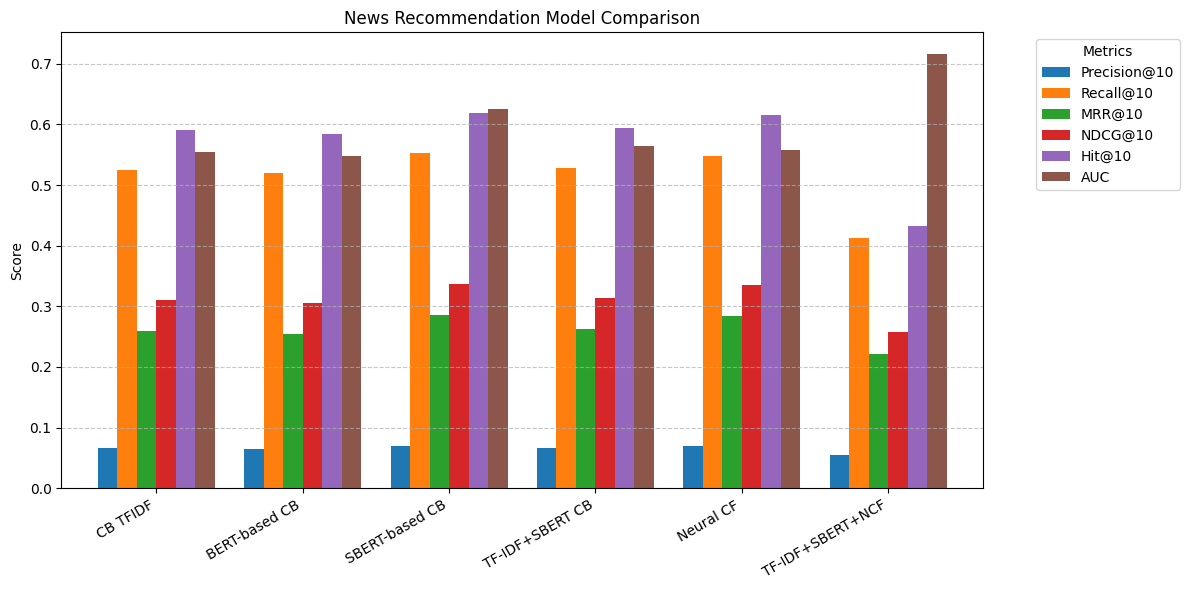

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame
data = {
    "CB TFIDF":              [0.0657, 0.5252, 0.2596, 0.3112, 0.5909, 0.5545],
    "BERT-based CB":         [0.0648, 0.5190, 0.2543, 0.3062, 0.5840, 0.5478],
    "SBERT-based CB":        [0.0698, 0.5520, 0.2854, 0.3368, 0.6191, 0.6252],
    "TF-IDF+SBERT CB":       [0.0662, 0.5283, 0.2618, 0.3137, 0.5942, 0.5648],
    "Neural CF":             [0.0692, 0.5482, 0.2845, 0.3351, 0.6152, 0.5572],
    "TF-IDF+SBERT+NCF":      [0.0550, 0.4130, 0.2216, 0.2577, 0.4318, 0.7159],
}
metrics = ["Precision@10", "Recall@10", "MRR@10", "NDCG@10", "Hit@10", "AUC"]

df = pd.DataFrame(data, index=metrics)

#
ax = df.T.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title("News Recommendation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


restrict the amount of context per user to simulate new community.

This project presents a comparative evaluation of various models applied to a personalized news recommendation system. The key objective is to predict user preferences effectively and deliver relevant news articles in real-time.

We evaluated six models based on different feature representations and architectures:

Content-Based (CB) using TF-IDF

CB using BERT and SBERT embeddings

Hybrid CB with TF-IDF + SBERT

Neural Collaborative Filtering (NCF)

Fully Hybrid model (TF-IDF + SBERT + NCF)

Across all evaluation metrics—including Precision@10, Recall@10, MRR@10, NDCG@10, Hit@10, and AUC—the SBERT-based content model showed strong performance, especially in ranking-based metrics (MRR and NDCG). The TF-IDF+SBERT+NCF hybrid model, despite having slightly lower Precision and Recall, achieved the highest AUC score (0.7159), indicating superior ability to distinguish between clicked and non-clicked items.

This suggests that combining collaborative signals with deep semantic content features (TF-IDF + SBERT) can effectively enhance user preference modeling. However, in some cases, simpler SBERT-based models without collaborative signals still perform competitively, highlighting the robustness of high-quality textual embeddings in content-based recommendations.

These findings support the use of hybrid architectures in news recommendation systems, balancing content understanding with user interaction modeling for optimal performance.



User Case Study

In [ ]:
def recommend_for_user(user_id, top_n=5, return_json=False):
    print("---GENERATING NEWS RECOMMENDATIONS FOR USER---")
    print(f"User ID: {user_id}")
    print(f"\n---TOP {top_n} RECOMMENDED NEWS ARTICLES ---")

    # Encode user ID
    user_idx = user_encoder.transform([user_id])[0]
    all_item_indices = np.arange(num_items)

    # Find already clicked items (Label == 1)
    seen_news_ids = interactions_df[
        (interactions_df['User_ID'] == user_id) & 
        (interactions_df['Label'] == 1)
    ]['News_ID'].unique()

    seen_indices = news_encoder.transform(seen_news_ids)
    
    # Filter out seen items
    unseen_mask = ~np.isin(all_item_indices, seen_indices)
    unseen_items = all_item_indices[unseen_mask]

    # Skip if nothing to recommend
    if len(unseen_items) == 0:
        print("No unseen items to recommend.")
        return pd.DataFrame()

    # Prepare input tensors
    user_tensor = torch.tensor([user_idx] * len(unseen_items), dtype=torch.long).to(device)
    item_tensor = torch.tensor(unseen_items, dtype=torch.long).to(device)

    # Predict scores
    model.eval()
    with torch.no_grad():
        scores = model(user_tensor, item_tensor).cpu().numpy().flatten()

    # Get top-N
    top_indices = np.argsort(-scores)[:top_n]
    top_item_ids = news_encoder.inverse_transform(unseen_items[top_indices])

    # Retrieve actual news info
    recommended = news[news['News_ID'].isin(top_item_ids)][['News_ID', 'Title', 'Category', 'SubCategory']]

    # Optional JSON return
    if return_json:
        return recommended.to_dict(orient='records')
    
    return recommended


In [ ]:
recommend_for_user("U64800", top_n=10)

---GENERATING NEWS RECOMMENDATIONS FOR USER---
User ID: U64800

---TOP 10 RECOMMENDED NEWS ARTICLES ---


,News_ID,Title,Category,SubCategory
33198,N50165,"CMA Awards 2019: How did Dolly Parton, Reba Mc...",music,cma-awards
41552,N63970,Dean Foods files for bankruptcy,finance,finance-companies
42756,N22696,Free Fight! Blachowicz Flatlines Rockhold In V...,sports,mma
43121,N35915,Four car chiefs ejected after pre-qualifying i...,sports,racing
44541,N25791,Opinions | We thought Trump was the biggest co...,news,newsopinion
45974,N53585,"Rip Taylor's Cause of Death Revealed, Memorial...",tv,tvnews
49398,N13825,Motorcyclist Dies After Falling 90 Feet Off Fo...,news,newsus
50365,N49279,Broadway Actress Laurel Griggs Dies at Age 13,music,musicnews
50688,N35729,Porsche launches into second story of New Jers...,news,newsus
50714,N49685,Broadway Star Laurel Griggs Suffered Asthma At...,music,music-celebrity
